<a href="https://colab.research.google.com/github/hapianalyst/Alzheimer-s-Disease-Classification-Using-DTI-Biomarkers/blob/main/Alzheimer%E2%80%99s_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Alzheimer’s Disease Progression: Machine Learning Classification of Alzheimer’s Disease and Mild Cognitive Impairment Using Diffusion Tensor Imaging (DTI) Biomarkers**

MSc Dissertation - Alzheimer's Disease Prediction

GitHub url: https://github.com/hapianalyst/Alzheimer-s-Disease-Classification-Using-DTI-Biomarkers


Research Questions:

1.   To what extent can ML algorithms accurately classify cognitive status using DTI-derived white matter features?

2.   Which specific DTI features are most strongly associated with Alzheimer's disease diagnosis?

3.   Does incorporating demographic variables improve model performance?


## **Importing Important Libraries**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.inspection import permutation_importance

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from scipy.stats import ttest_rel


# Utilities
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Install imbalanced-learn for SMOTE
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'], check=True)

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import RandomizedSearchCV

print("All libraries imported successfully")

All libraries imported successfully


## **Set-up Environment and Load the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Load the dataset
file_path = '/content/drive/MyDrive/ADSP_PHC_DTI_May2025.csv'

df = pd.read_csv(file_path)

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"First few columns: {df.columns[:10].tolist()}")

Dataset loaded successfully
Shape: 3,026 rows × 13,771 columns
First few columns: ['RID', 'PTID', 'PHASE', 'VISCODE2', 'VISCODE', 'PHC_LONIUID', 'SUBJID', 'PHC_Visit', 'PHC_Age_Cognition', 'PHC_Age_DTI']


In [ ]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3026 entries, 0 to 3025
Columns: 13771 entries, RID to edge_count
dtypes: float64(13754), int64(9), object(8)
memory usage: 317.9+ MB


## **Data Structure**

In [ ]:
# Data types overview
print("DATA TYPES DISTRIBUTION")
print(df.dtypes.value_counts())

# Identify column types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

DATA TYPES DISTRIBUTION
float64    13754
int64          9
object         8
Name: count, dtype: int64
Numerical columns: 13763
Categorical columns: 8


# **Finding Missing Values**

In [ ]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

print(f"MISSING VALUES SUMMARY")
print(f"Total columns with missing values: {len(missing_data)}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print(f"Overall missingness: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

if len(missing_data) > 0:
    print(f"Top columns with missing values:")
    display(missing_data.head(5))
else:
    print("No missing values detected!")

MISSING VALUES SUMMARY
Total columns with missing values: 8954
Total missing values: 617,510
Overall missingness: 1.48%
Top columns with missing values:


,Column,Missing_Count,Missing_Percentage
t1seg_3rd_ventricle_fwcorrected_rd_median,t1seg_3rd_ventricle_fwcorrected_rd_median,3026,100.0
t1seg_3rd_ventricle_fwcorrected_ad_median,t1seg_3rd_ventricle_fwcorrected_ad_median,3026,100.0
t1seg_3rd_ventricle_fwcorrected_md_median,t1seg_3rd_ventricle_fwcorrected_md_median,3026,100.0
t1seg_3rd_ventricle_fwcorrected_fa_median,t1seg_3rd_ventricle_fwcorrected_fa_median,3026,100.0
t1seg_right_lateral_ventricle_fwcorrected_ad_median,t1seg_right_lateral_ventricle_fwcorrected_ad_m...,3026,100.0


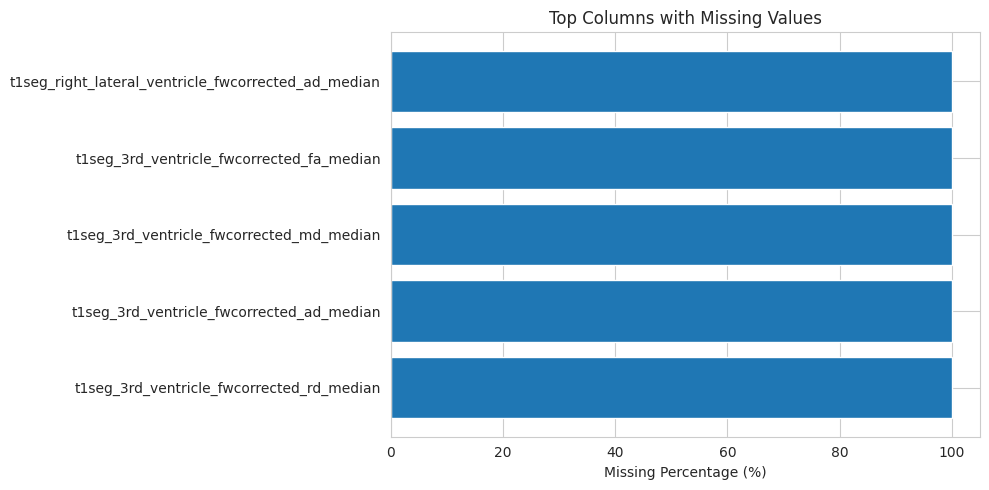

In [ ]:
# Visualize missing values pattern
if len(missing_data) > 0:
    top_missing = missing_data.head(5)

    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'])
    plt.yticks(range(len(top_missing)), top_missing['Column'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top Columns with Missing Values')
    plt.tight_layout()
    plt.show()

# **Duplicate Detection and Removal**

In [ ]:
# Check for duplicate rows
print("DUPLICATE DETECTION")
print(f"Original dataset: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

# Check complete duplicate rows
complete_dups = df.duplicated().sum()
print(f"Complete duplicate rows: {complete_dups:,}")

# Check duplicates based on patient identifiers
if 'RID' in df.columns:
    rid_dups = df.duplicated(subset=['RID']).sum()
    print(f"Duplicate RID entries: {rid_dups:,}")

if 'RID' in df.columns and 'VISCODE' in df.columns:
    rid_visit_dups = df.duplicated(subset=['RID', 'VISCODE']).sum()
    print(f"Duplicate RID+VISCODE entries: {rid_visit_dups:,}")

if 'PTID' in df.columns and 'VISCODE' in df.columns:
    ptid_visit_dups = df.duplicated(subset=['PTID', 'VISCODE']).sum()
    print(f"Duplicate PTID+VISCODE entries: {ptid_visit_dups:,}")

DUPLICATE DETECTION
Original dataset: 3,026 rows × 13,771 columns
Complete duplicate rows: 0
Duplicate RID entries: 1,775
Duplicate RID+VISCODE entries: 0
Duplicate PTID+VISCODE entries: 0


In [ ]:
# Show examples of duplicate entries
if 'RID' in df.columns and 'VISCODE' in df.columns:
    dup_mask = df.duplicated(subset=['RID', 'VISCODE'], keep=False)

    if dup_mask.sum() > 0:
        print("EXAMPLE DUPLICATE ENTRIES (RID + VISCODE):")


        # Show identifier columns plus a few key columns
        display_cols = ['RID', 'PTID', 'VISCODE', 'PHC_Visit', 'PHC_Age_DTI']
        display_cols = [col for col in display_cols if col in df.columns]

        dup_examples = df[dup_mask][display_cols].sort_values(['RID', 'VISCODE']).head(20)
        display(dup_examples)

        # Count how many RID+VISCODE combinations are duplicated
        dup_combos = df[dup_mask].groupby(['RID', 'VISCODE']).size()
        print(f"\nNumber of duplicated RID+VISCODE combinations: {len(dup_combos)}")
        print(f"Maximum duplicates for one combination: {dup_combos.max()}")
    else:
        print("No duplicate RID+VISCODE entries found.")

No duplicate RID+VISCODE entries found.


In [ ]:
# Remove duplicates
print("REMOVING DUPLICATES")

# Keep one scan per patient per visit

if 'RID' in df.columns and 'VISCODE' in df.columns:
    print("Keeping one scan per patient per visit (RID + VISCODE)")
    df_clean = df.drop_duplicates(subset=['RID', 'VISCODE'], keep='first')
elif 'RID' in df.columns:
    print("Keeping one scan per patient (RID only)")
    df_clean = df.drop_duplicates(subset=['RID'], keep='first')
else:
    print("Removing complete duplicate rows")
    df_clean = df.drop_duplicates()

# Reset index
df_clean = df_clean.reset_index(drop=True)

# Report results
rows_removed = df.shape[0] - df_clean.shape[0]
print(f"Cleaned dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]:,} columns")
print(f"Rows removed: {rows_removed:,}")
print(f"Percentage removed: {(rows_removed / df.shape[0] * 100):.2f}%")

if rows_removed > 0:
    print("Duplicates removed successfully!")
    print("Using df_clean for all subsequent analysis")
else:
    print("No duplicates found!")

# Use df_clean for all subsequent analyses
df = df_clean

REMOVING DUPLICATES
Keeping one scan per patient per visit (RID + VISCODE)
Cleaned dataset: 3,026 rows × 13,771 columns
Rows removed: 0
Percentage removed: 0.00%
No duplicates found!


# **Summary**

In [ ]:
# Comprehensive summary statistics
if len(numerical_cols) > 0:
    summary_stats = df[numerical_cols].describe().T
    summary_stats['missing'] = df[numerical_cols].isnull().sum()
    summary_stats['missing_pct'] = (df[numerical_cols].isnull().sum() / len(df) * 100).round(2)
    summary_stats['skewness'] = df[numerical_cols].skew().round(2)
    summary_stats['kurtosis'] = df[numerical_cols].kurtosis().round(2)

    print("NUMERICAL FEATURES SUMMARY")
    display(summary_stats.head(10))

NUMERICAL FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct,skewness,kurtosis
RID,3026.0,5001.031064,1616.613072,21.000000,4336.250000,5.017500e+03,6.369000e+03,7.115000e+03,0,0.00,-0.98,0.55
PHC_LONIUID,3026.0,917536.706543,442595.958167,189995.000000,393786.750000,1.003314e+06,1.270046e+06,1.644377e+06,0,0.00,-0.19,-1.33
PHC_Visit,1925.0,4.817662,3.169583,1.000000,2.000000,4.000000e+00,7.000000e+00,1.600000e+01,1101,36.38,1.07,0.50
PHC_Age_Cognition,3026.0,74.548274,7.543572,50.450376,69.407940,7.452977e+01,7.968720e+01,9.597536e+01,0,0.00,0.01,-0.21
PHC_Age_DTI,3026.0,74.576583,7.542653,50.532512,69.424367,7.455578e+01,7.969815e+01,9.597536e+01,0,0.00,0.01,-0.21
PHC_Diagnosis,2550.0,1.645098,0.691203,1.000000,1.000000,2.000000e+00,2.000000e+00,3.000000e+00,476,15.73,0.60,-0.77
PHC_Sex,3026.0,1.479841,0.499676,1.000000,1.000000,1.000000e+00,2.000000e+00,2.000000e+00,0,0.00,0.08,-1.99
PHC_Race,3026.0,4.818903,0.692524,1.000000,5.000000,5.000000e+00,5.000000e+00,6.000000e+00,0,0.00,-2.99,8.87
PHC_Ethnicity,3005.0,1.938436,0.240402,1.000000,2.000000,2.000000e+00,2.000000e+00,2.000000e+00,21,0.69,-3.65,11.33
PHC_Education,3026.0,16.294779,2.572779,8.000000,14.000000,1.600000e+01,1.800000e+01,2.000000e+01,0,0.00,-0.35,-0.64


# **Categorical Variables Analysis**

In [ ]:
# Analyze categorical variables
if len(categorical_cols) > 0:
    print("CATEGORICAL VARIABLES")

# Show first 5
    for col in categorical_cols[:5]:
        n_unique = df[col].nunique()
        print(f"{col}:")
        print(f"Unique values: {n_unique}")

        if n_unique <= 20:
            print(f"Value counts:")
            print(df[col].value_counts())
        else:
            print(f"Top 5 values:")
            print(df[col].value_counts().head(5))

CATEGORICAL VARIABLES
PTID:
Unique values: 1251
Top 5 values:
PTID
027_S_2245    14
127_S_2234    13
027_S_4869    12
127_S_4210    12
027_S_4919    11
Name: count, dtype: int64
PHASE:
Unique values: 3
Value counts:
PHASE
ADNI3     1980
ADNI2      949
ADNIGO      97
Name: count, dtype: int64
VISCODE2:
Unique values: 35
Top 5 values:
VISCODE2
sc       704
m12      353
m24      319
scmri    236
m03      187
Name: count, dtype: int64
VISCODE:
Unique values: 20
Value counts:
VISCODE
sc       704
y2       398
y1       332
init     293
v02      198
v11      171
v04      160
y4       157
v21      151
v05      133
y3        83
v41       50
v31       47
scmri     38
v06       30
m03       27
m06       27
y5        13
v51        9
m12        5
Name: count, dtype: int64
SUBJID:
Unique values: 987
Top 5 values:
SUBJID
ADNI_027_S_2245    14
ADNI_127_S_2234    13
ADNI_127_S_4210    12
G-ADNI-AN000132    12
G-ADNI-AN000138    11
Name: count, dtype: int64


# **Identify Potential Target Variable**

In [ ]:
# Identify the target variable
possible_targets = ['DIAGNOSIS','COGNITION','DX']

target_col = None
for col in df.columns:
    if col in possible_targets or 'DX' in col.upper():
        if df[col].nunique() > 1 and df[col].nunique() < 5:  # Reasonable number of classes
            print(f"Found potential target: {col}")
            print(f"Unique values: {df[col].unique()}")
            print(f"  Value counts:\n{df[col].value_counts()}\n")

In [ ]:
TARGET_COLUMN = 'PHC_Diagnosis'
# Verify target column exists
if TARGET_COLUMN not in df.columns:
    print(f"Column '{TARGET_COLUMN}' not found.")
else:
    print(f"Target column set: {TARGET_COLUMN}")
    print(f"Class distribution:")
    print(df[TARGET_COLUMN].value_counts())
    print(f"Class proportions:")
    print(df[TARGET_COLUMN].value_counts(normalize=True).round(3))

Target column set: PHC_Diagnosis
Class distribution:
PHC_Diagnosis
1.0    1222
2.0    1011
3.0     317
Name: count, dtype: int64
Class proportions:
PHC_Diagnosis
1.0    0.479
2.0    0.396
3.0    0.124
Name: proportion, dtype: float64


In [ ]:
print("CHECKING DIAGNOSIS CODE MAPPING")

# Step 1: Show unique numeric diagnosis codes
print("Unique values in PHC_Diagnosis:")
print(sorted(df['PHC_Diagnosis'].unique()))

# Step 2: Search for possible text diagnosis columns
possible_text_cols = [
    col for col in df.columns
    if df[col].dtype == 'object' and df[col].nunique() <= 10
]

print("Possible categorical diagnosis columns found:")
print(possible_text_cols)

# Step 3: Cross-tabulate numeric codes with possible text columns
for col in possible_text_cols:
    print(f"Cross-tabulation between PHC_Diagnosis and {col}:")
    print(pd.crosstab(df['PHC_Diagnosis'], df[col]))

CHECKING DIAGNOSIS CODE MAPPING
Unique values in PHC_Diagnosis:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(nan)]
Possible categorical diagnosis columns found:
['PHASE', 'Manufacturer']
Cross-tabulation between PHC_Diagnosis and PHASE:
PHASE          ADNI2  ADNI3  ADNIGO
PHC_Diagnosis                      
1.0              198   1023       1
2.0              268    712      31
3.0              121    196       0
Cross-tabulation between PHC_Diagnosis and Manufacturer:
Manufacturer    GE  Philips  Siemens
PHC_Diagnosis                       
1.0            449      114      659
2.0            495      119      397
3.0            179       29      109


In [ ]:
# Demographic features
demographic_features = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in ['age', 'sex', 'gender', 'education', 'ethnicity', 'race', 'apoe']):
        demographic_features.append(col)

print(f"Identified Demographic Features ({len(demographic_features)}):")
print(demographic_features)

# DTI-specific features (fractional anisotropy, mean diffusivity, etc.)
dti_keywords = ['fa', 'md', 'rd', 'ad', 'dti', 'tract', 'diffusion',
                'anisotropy', 'diffusivity', 'fiber', 'white_matter',
                'assortativity', 'participation', 'clustering', 'nodal_strength',
                'efficiency', 'density', 'rich_club', 'path_length', 'edge_count']

dti_features = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in dti_keywords):
        if col != TARGET_COLUMN and col not in demographic_features:
            dti_features.append(col)

print(f"Identified DTI Features ({len(dti_features)}):")
print(f"First 10 DTI features: {dti_features[:10]}")

# Identifier columns to exclude
id_columns = ['RID', 'PTID', 'SUBJID', 'PHASE', 'VISCODE', 'VISCODE2',
              'PHC_LONIUID', 'PHC_Visit']

print(f"Identifier columns to exclude: {id_columns}")

Identified Demographic Features (6):
['PHC_Age_Cognition', 'PHC_Age_DTI', 'PHC_Sex', 'PHC_Race', 'PHC_Ethnicity', 'PHC_Education']
Identified DTI Features (11015):
First 10 DTI features: ['Manufacturer', 'NumberOfDiffusionDirections', 'PHC_jhu_superior_parietal_wm_left_fa_median', 'PHC_jhu_superior_parietal_wm_left_fa_mean', 'PHC_jhu_superior_parietal_wm_left_fa_std', 'PHC_jhu_superior_parietal_wm_left_md_median', 'PHC_jhu_superior_parietal_wm_left_md_mean', 'PHC_jhu_superior_parietal_wm_left_md_std', 'PHC_jhu_superior_parietal_wm_left_ad_median', 'PHC_jhu_superior_parietal_wm_left_ad_mean']
Identifier columns to exclude: ['RID', 'PTID', 'SUBJID', 'PHASE', 'VISCODE', 'VISCODE2', 'PHC_LONIUID', 'PHC_Visit']


# **Distribution Analysis**

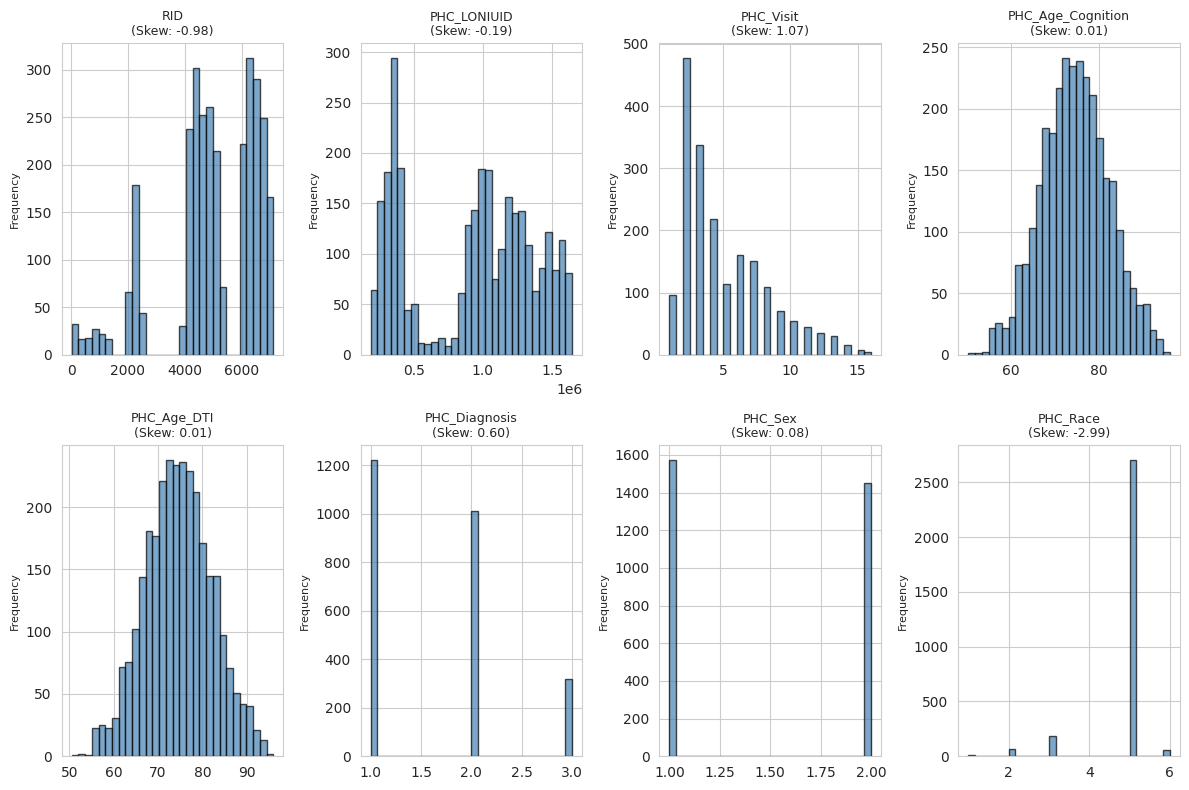

In [ ]:
# Plot distributions for selected features
if len(numerical_cols) > 0:
    # Select first 8 numerical columns
    cols_to_plot = numerical_cols[:8]

    fig, axes = plt.subplots(2, 4, figsize=(12, 8))
    axes = axes.flatten()

    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'{col}\n(Skew: {df[col].skew():.2f})', fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('Frequency', fontsize=8)

    plt.tight_layout()
    plt.show()

# **Correlation Analysis**

In [ ]:
# Calculate correlation matrix
if len(numerical_cols) > 1:
    print("CORRELATION ANALYSIS")

    # For large datasets, sample columns for correlation analysis
    cols_for_corr = numerical_cols[:100] if len(numerical_cols) > 100 else numerical_cols

    correlation_matrix = df[cols_for_corr].corr()

    # Find highly correlated pairs
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:  # High correlation threshold
                high_corr.append({
                    'Feature_1': correlation_matrix.columns[i],
                    'Feature_2': correlation_matrix.columns[j],
                    'Correlation': round(corr_value, 3)
                })

    if high_corr:
        high_corr_df = pd.DataFrame(high_corr).sort_values(
            'Correlation', key=abs, ascending=False
        )
        print(f"Highly correlated pairs (|r| > 0.8): {len(high_corr_df)}")
        display(high_corr_df.head(10))
    else:
        print("No highly correlated pairs found (|r| > 0.8).")

CORRELATION ANALYSIS
Highly correlated pairs (|r| > 0.8): 118


,Feature_1,Feature_2,Correlation
1,PHC_Age_Cognition,PHC_Age_DTI,1.000
2,PixelSpacing_X,PixelSpacing_Y,1.000
29,PHC_jhu_caudate_nucleus_left_md_median,PHC_jhu_caudate_nucleus_left_rd_median,0.999
28,PHC_jhu_caudate_nucleus_left_md_median,PHC_jhu_caudate_nucleus_left_ad_median,0.998
33,PHC_jhu_caudate_nucleus_left_ad_median,PHC_jhu_caudate_nucleus_left_rd_median,0.995
32,PHC_jhu_caudate_nucleus_left_md_std,PHC_jhu_caudate_nucleus_left_rd_std,0.995
17,PHC_jhu_superior_parietal_wm_left_md_std,PHC_jhu_superior_parietal_wm_left_rd_std,0.994
68,PHC_jhu_middle_frontal_wm_left_md_std,PHC_jhu_middle_frontal_wm_left_rd_std,0.994
108,PHC_jhu_precentral_wm_left_md_std,PHC_jhu_precentral_wm_left_rd_std,0.994
46,PHC_jhu_superior_frontal_wm_left_md_std,PHC_jhu_superior_frontal_wm_left_rd_std,0.991


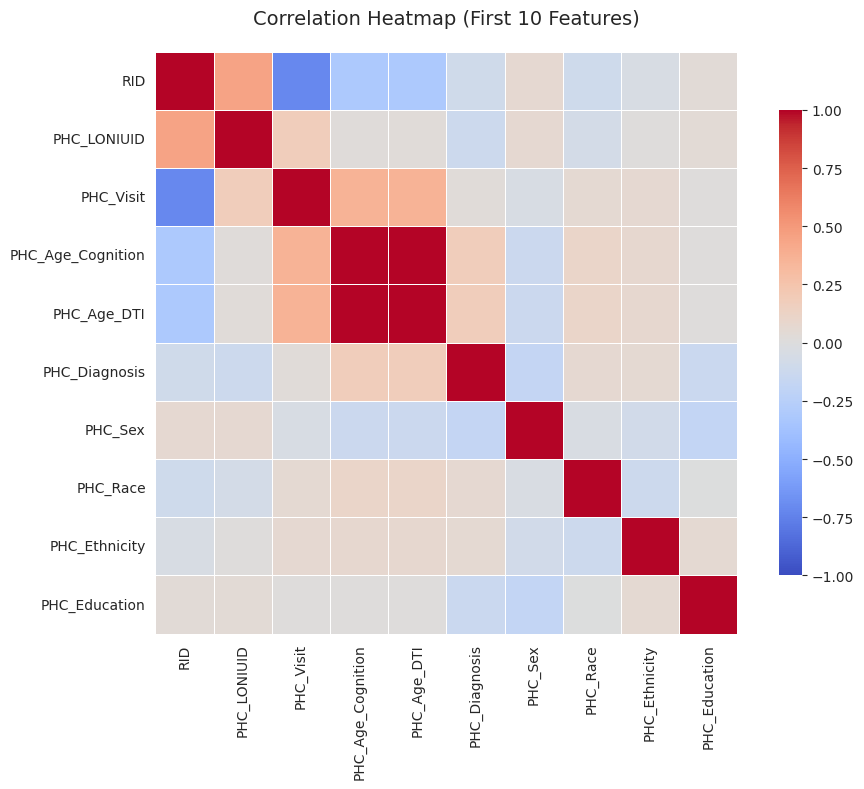

In [ ]:
# Visualize correlation heatmap
if len(numerical_cols) > 1:
    # Select subset for visualization
    cols_for_viz = numerical_cols[:10] if len(numerical_cols) > 30 else numerical_cols

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        df[cols_for_viz].corr(),
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'Correlation Heatmap (First {len(cols_for_viz)} Features)', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

# **Outlier Detection**

In [ ]:
# Detect outliers using IQR method
print("OUTLIER DETECTION (IQR Method)")

# Check first 50 columns
outlier_summary = []
for col in numerical_cols[:50]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df) * 100)

    if n_outliers > 0:
        outlier_summary.append({
            'Column': col,
            'N_Outliers': n_outliers,
            'Percentage': round(pct_outliers, 2),
            'Lower_Bound': round(lower_bound, 3),
            'Upper_Bound': round(upper_bound, 3)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('N_Outliers', ascending=False)
    print(f"Columns with outliers: {len(outlier_df)}")
    display(outlier_df.head(10))
else:
    print("No outliers detected using IQR method.")

OUTLIER DETECTION (IQR Method)
Columns with outliers: 41


,Column,N_Outliers,Percentage,Lower_Bound,Upper_Bound
12,NumberOfDiffusionDirections,592,19.56,32.500,68.500
4,PHC_Race,321,10.61,5.000,5.000
8,EchoTime,193,6.38,0.039,0.096
18,PHC_jhu_superior_parietal_wm_left_md_std,186,6.15,0.000,0.000
5,PHC_Ethnicity,185,6.11,2.000,2.000
37,PHC_jhu_superior_frontal_wm_left_md_std,181,5.98,-0.001,0.001
21,PHC_jhu_superior_parietal_wm_left_ad_std,179,5.92,0.000,0.000
39,PHC_jhu_superior_frontal_wm_left_ad_std,179,5.92,-0.000,0.001
24,PHC_jhu_superior_parietal_wm_left_rd_std,176,5.82,0.000,0.000
6,Imaging_Site,138,4.56,-135.500,284.500


# **Boxplot Visualization**

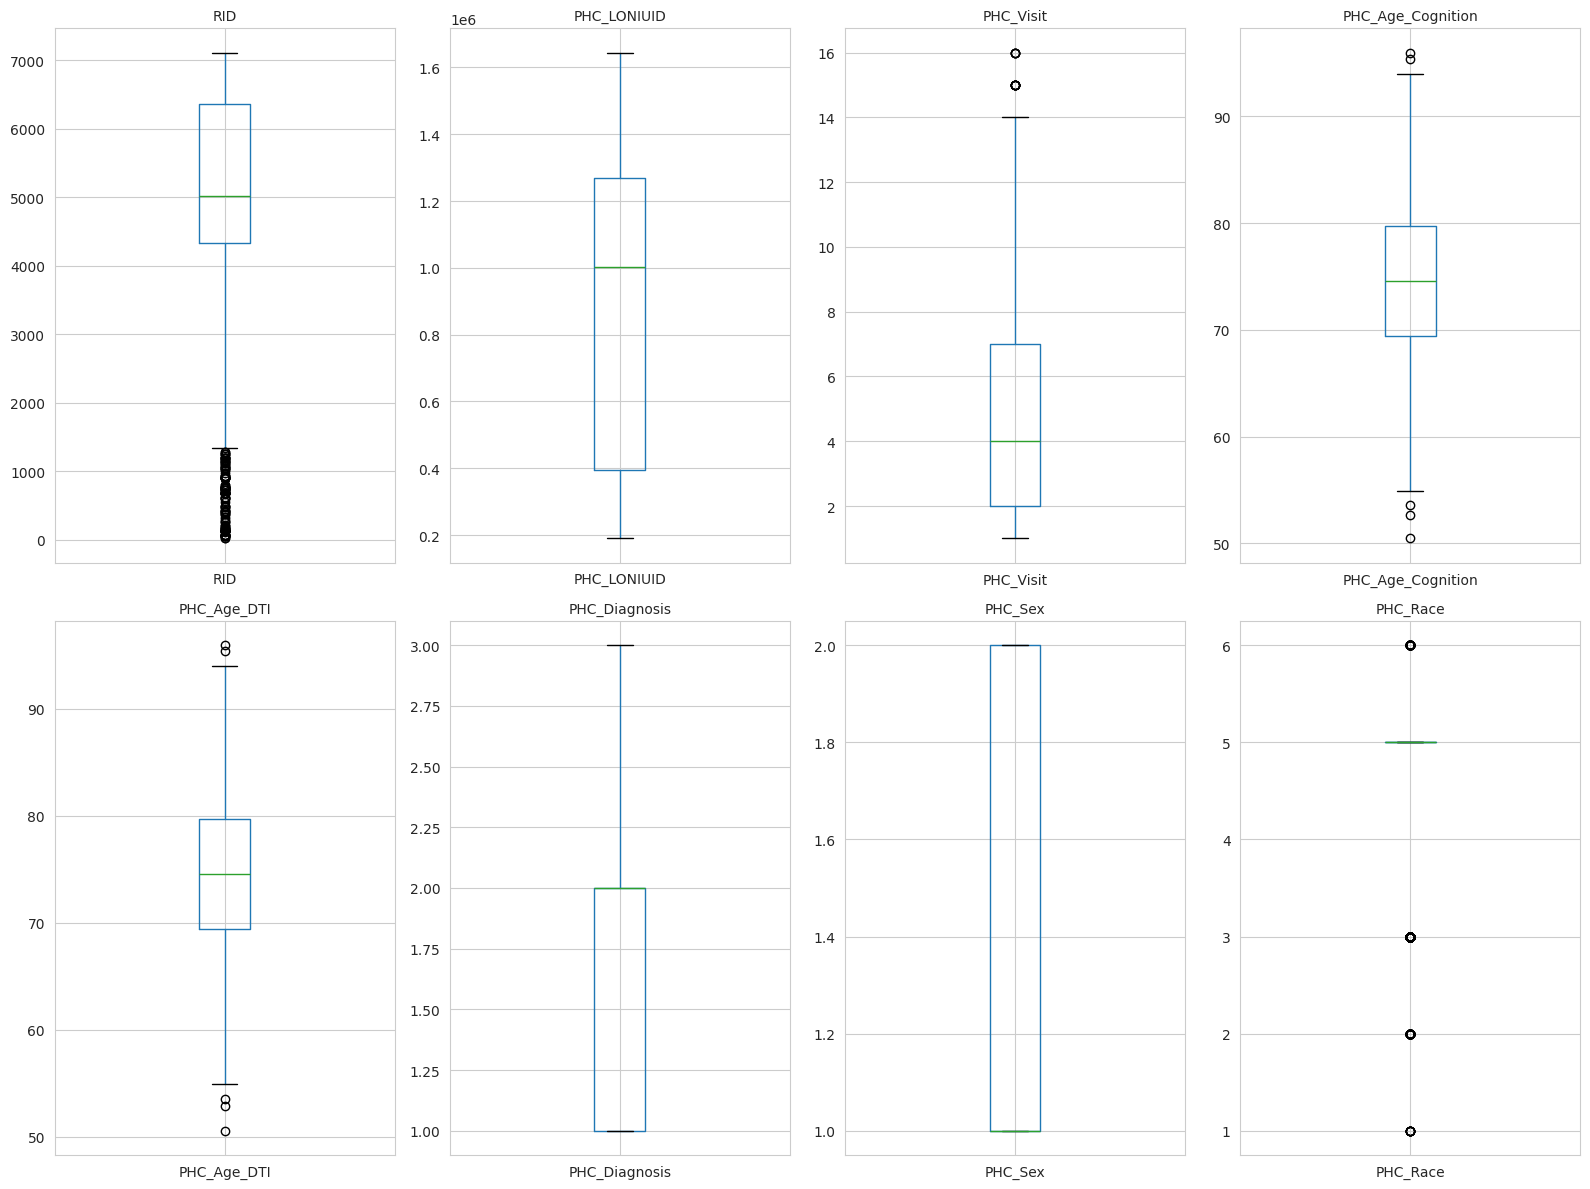

In [ ]:
# Create boxplots for selected features
if len(numerical_cols) > 0:
    cols_to_plot = numerical_cols[:8]

    fig, axes = plt.subplots(2, 4, figsize=(16, 12))
    axes = axes.flatten()

    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        df.boxplot(column=col, ax=ax)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('')

    plt.tight_layout()
    plt.show()

# **Data Quality Summary**

In [ ]:
print("COMPREHENSIVE DATA QUALITY SUMMARY")

print(f"DATASET DIMENSIONS:")
print(f"  • Total rows: {df.shape[0]:,}")
print(f"  • Total columns: {df.shape[1]:,}")
print(f"  • Numerical features: {len(numerical_cols):,}")
print(f"  • Categorical features: {len(categorical_cols):,}")

print(f"DATA COMPLETENESS:")
print(f"  • Total missing values: {df.isnull().sum().sum():,}")
print(f"  • Missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
print(f"  • Columns with missing data: {(df.isnull().sum() > 0).sum():,}")

print(f"DATA QUALITY:")
print(f"  • Duplicate rows: {df.duplicated().sum():,}")
if outlier_summary:
    print(f"  • Columns with outliers: {len(outlier_df):,}")

print(f"MEMORY USAGE:")
print(f"  • Total memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")




COMPREHENSIVE DATA QUALITY SUMMARY
DATASET DIMENSIONS:
  • Total rows: 3,026
  • Total columns: 13,771
  • Numerical features: 13,763
  • Categorical features: 8
DATA COMPLETENESS:
  • Total missing values: 617,510
  • Missing percentage: 1.48%
  • Columns with missing data: 8,954
DATA QUALITY:
  • Duplicate rows: 0
  • Columns with outliers: 41
MEMORY USAGE:
  • Total memory: 319.03 MB


# **Data Preprocessing**

In [ ]:
print("FEATURE SELECTION")

# Columns to EXCLUDE from features
exclude_cols = [
    # ID columns
    'RID', 'PTID', 'PHASE', 'VISCODE2', 'VISCODE',
    'PHC_LONIUID', 'SUBJID', 'PHC_Visit',
    # Target
    'PHC_Diagnosis',
    # Multicollinear with PHC_Age_DTI
    'PHC_Age_Cognition'
]

# Demographic features to KEEP
demographic_features = [
    'PHC_Age_DTI',
    'PHC_Sex',
    'PHC_Race',
    'PHC_Ethnicity',
    'PHC_Education'
]

# Get all numeric columns
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove excluded columns
feature_cols = [col for col in all_numeric_cols if col not in exclude_cols]

print(f"Total columns in dataset: {len(df.columns)}")
print(f"Total numeric columns: {len(all_numeric_cols)}")
print(f"Excluded columns: {len(exclude_cols)}")
print(f"Selected features: {len(feature_cols)}")

# Check which demographic features are included
included_demographics = [col for col in demographic_features if col in feature_cols]
print(f"Demographic features included: {len(included_demographics)}")
for col in included_demographics:
    print(f"{col}")

# Estimate DTI features
dti_features = [col for col in feature_cols if col not in demographic_features]
print(f"DTI features: {len(dti_features)}")
print(f"First 10 DTI features:")
for i, col in enumerate(dti_features[:10], 1):
    print(f"  {i}. {col}")


print("Features selected successfully!")

FEATURE SELECTION
Total columns in dataset: 13771
Total numeric columns: 13763
Excluded columns: 10
Selected features: 13758
Demographic features included: 5
PHC_Age_DTI
PHC_Sex
PHC_Race
PHC_Ethnicity
PHC_Education
DTI features: 13753
First 10 DTI features:
  1. Imaging_Site
  2. FieldStrength
  3. RepetitionTime
  4. EchoTime
  5. FlipAngle
  6. PixelSpacing_X
  7. PixelSpacing_Y
  8. SliceThickness
  9. NumberOfDiffusionDirections
  10. PHC_jhu_superior_parietal_wm_left_fa_median
Features selected successfully!


Prepare Features (X) and Target (y)

In [ ]:
print("PREPARING FEATURES AND TARGET")

# Extract features (X) and target (y)
X = df[feature_cols].copy()
y = df[TARGET_COLUMN].copy()

print(f"Features (X): {X.shape}")
print(f"Demographics: {len(included_demographics)}")
print(f"DTI features: {len(dti_features)}")

print(f"Target (y): {y.shape}")
print(f"Unique classes: {y.nunique()}")
print(f"Class distribution:")
for label, count in y.value_counts().items():
    pct = (count / len(y)) * 100
    print(f"{label}: {count:,} ({pct:.1f}%)")

print("X and y prepared successfully!")

PREPARING FEATURES AND TARGET
Features (X): (3026, 13758)
Demographics: 5
DTI features: 13753
Target (y): (3026,)
Unique classes: 3
Class distribution:
1.0: 1,222 (40.4%)
2.0: 1,011 (33.4%)
3.0: 317 (10.5%)
X and y prepared successfully!


# Missing Values Analysis

In [ ]:
print("MISSING VALUES ANALYSIS")

# Check missing values in features
missing_counts = df[feature_cols].isnull().sum()
features_with_missing = missing_counts[missing_counts > 0]

print(f"Features with missing values: {len(features_with_missing)} / {len(feature_cols)}")

if len(features_with_missing) > 0:
    print(f"Top 10 features with most missing values:")
    top_missing = features_with_missing.sort_values(ascending=False).head(10)

    for col, count in top_missing.items():
        pct = (count / len(df)) * 100
        print(f"{col}: {count:,} ({pct:.1f}%)")

    total_missing = df[feature_cols].isnull().sum().sum()
    total_cells = len(df) * len(feature_cols)
    print(f"Total missing: {total_missing:,} / {total_cells:,} ({(total_missing/total_cells)*100:.2f}%)")
    print("Missing values will be imputed using median strategy")
else:
    print("No missing values found!")

# Check missing in demographics specifically
print(f"DEMOGRAPHIC FEATURES COMPLETENESS:")
for col in included_demographics:
    missing = df[col].isnull().sum()
    pct = (missing / len(df)) * 100
    status = "✓" if missing == 0 else "⚠️"
    print(f"  {status} {col}: {missing:,} missing ({pct:.1f}%)")

MISSING VALUES ANALYSIS
Features with missing values: 8951 / 13758
Top 10 features with most missing values:
t1seg_3rd_ventricle_fwcorrected_ad_median: 3,026 (100.0%)
t1seg_3rd_ventricle_fwcorrected_rd_median: 3,026 (100.0%)
t1seg_3rd_ventricle_fwcorrected_md_median: 3,026 (100.0%)
t1seg_3rd_ventricle_fwcorrected_fa_median: 3,026 (100.0%)
t1seg_right_lateral_ventricle_fwcorrected_md_median: 3,026 (100.0%)
t1seg_right_lateral_ventricle_fwcorrected_fa_median: 3,026 (100.0%)
t1seg_right_lateral_ventricle_fwcorrected_rd_median: 3,026 (100.0%)
t1seg_right_lateral_ventricle_fwcorrected_ad_median: 3,026 (100.0%)
t1seg_left_lateral_ventricle_fwcorrected_rd_median: 3,021 (99.8%)
t1seg_left_lateral_ventricle_fwcorrected_ad_median: 3,021 (99.8%)
Total missing: 615,634 / 41,631,708 (1.48%)
Missing values will be imputed using median strategy
DEMOGRAPHIC FEATURES COMPLETENESS:
  ✓ PHC_Age_DTI: 0 missing (0.0%)
  ✓ PHC_Sex: 0 missing (0.0%)
  ✓ PHC_Race: 0 missing (0.0%)
  ⚠️ PHC_Ethnicity: 21 missi

# Target Variable Inspection

In [ ]:
print("Missing y:", y.isna().sum())
print("y value counts (after drop):")
print(y.value_counts())

Missing y: 476
y value counts (after drop):
PHC_Diagnosis
1.0    1222
2.0    1011
3.0     317
Name: count, dtype: int64


# Train-Test Split (80/20)

In [ ]:
# Combine X and y to drop matching rows safely
data = pd.concat([X, y], axis=1)

# Drop rows where target is missing
data = data.dropna(subset=[y.name])

# Split back into X and y
X = data.drop(columns=[y.name])
y = data[y.name]

print(f"Remaining samples after removing NaNs: {len(y):,}")
print(f"Remaining NaNs in y: {y.isna().sum()}")

Remaining samples after removing NaNs: 2,550
Remaining NaNs in y: 0


In [ ]:
print("TRAIN-TEST SPLIT")

# Split configuration
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # Maintains class distribution
)

print(f"Split ratio: {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}")
print(f"Random state: {RANDOM_STATE}")
print(f"Stratified: Yes")

print(f"Train set: {X_train.shape[0]:,} samples ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({TEST_SIZE*100:.0f}%)")

print(f"Train set class distribution:")
for label, count in y_train.value_counts().items():
    pct = (count / len(y_train)) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

print(f"Test set class distribution:")
for label, count in y_test.value_counts().items():
    pct = (count / len(y_test)) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

print("Data split successfully!")

TRAIN-TEST SPLIT
Split ratio: 80/20
Random state: 42
Stratified: Yes
Train set: 2,040 samples (80%)
Test set: 510 samples (20%)
Train set class distribution:
  1.0: 977 (47.9%)
  2.0: 809 (39.7%)
  3.0: 254 (12.5%)
Test set class distribution:
  1.0: 245 (48.0%)
  2.0: 202 (39.6%)
  3.0: 63 (12.4%)
Data split successfully!


# Encode Target Variable

In [ ]:
print("ENCODING TARGET VARIABLE")

# Check if target needs encoding
if y_train.dtype == 'object' or y_train.dtype.name == 'category':
    print(f"Target type: {y_train.dtype} (needs encoding)")

    # Initialize label encoder
    label_encoder = LabelEncoder()

    # Fit on training data
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    # Show encoding mapping
    print(f"Class encoding mapping:")
    for i, label in enumerate(label_encoder.classes_):
        count_train = (y_train_encoded == i).sum()
        print(f"  '{label}' → {i} ({count_train:,} samples in train)")

    # Update y_train and y_test
    y_train = pd.Series(y_train_encoded, name=TARGET_COLUMN, index=y_train.index)
    y_test = pd.Series(y_test_encoded, name=TARGET_COLUMN, index=y_test.index)

    print("Target encoded successfully!")
else:
    label_encoder = None
    print(f"Target type: {y_train.dtype} (already numeric)")
    print("Target encoding not needed!")

print(f"Final target distribution (train):")
print(y_train.value_counts().sort_index())

ENCODING TARGET VARIABLE
Target type: float64 (already numeric)
Target encoding not needed!
Final target distribution (train):
PHC_Diagnosis
1.0    977
2.0    809
3.0    254
Name: count, dtype: int64


In [ ]:
# ✅ Ensure classes are 0..K-1
y_train = y_train.astype(int)
y_test = y_test.astype(int)

unique_classes = sorted(y_train.unique())
class_map = {old: new for new, old in enumerate(unique_classes)}

y_train = y_train.map(class_map)
y_test = y_test.map(class_map)

print("Remapped target classes:", class_map)
print("Train classes now:", sorted(y_train.unique()))


Remapped target classes: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
Train classes now: [np.int64(0), np.int64(1), np.int64(2)]


# Feature Scaling (Standardization)

In [ ]:
print("CLEANING + IMPUTATION + SCALING")

# Ensure numeric (turn non-numeric into NaN)
X_train_num = X_train.apply(pd.to_numeric, errors="coerce")
X_test_num  = X_test.apply(pd.to_numeric, errors="coerce")

# Replace inf/-inf with NaN
X_train_num = X_train_num.replace([np.inf, -np.inf], np.nan)
X_test_num  = X_test_num.replace([np.inf, -np.inf], np.nan)

# Drop columns that are ALL NaN in TRAIN (they can't be imputed by median)
all_nan_cols = X_train_num.columns[X_train_num.isna().all()]
if len(all_nan_cols) > 0:
    print(f"Dropping {len(all_nan_cols)} columns with all-NaN in TRAIN")
    X_train_num = X_train_num.drop(columns=all_nan_cols)
    X_test_num  = X_test_num.drop(columns=all_nan_cols)

# Fill missing values using TRAIN medians
train_medians = X_train_num.median(numeric_only=True)
X_train_num = X_train_num.fillna(train_medians)
X_test_num  = X_test_num.fillna(train_medians)

# Final safety net: if any NaNs still remain, fill with 0
nans_left_train = X_train_num.isna().sum().sum()
nans_left_test  = X_test_num.isna().sum().sum()
if nans_left_train > 0 or nans_left_test > 0:
    print(f"NaNs still found (train={nans_left_train}, test={nans_left_test}). Filling remaining NaNs with 0.")
    X_train_num = X_train_num.fillna(0)
    X_test_num  = X_test_num.fillna(0)

# Scale - fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled  = scaler.transform(X_test_num)

# Put back into DataFrames
feature_cols = X_train_num.columns
X_train = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

print("Cleaning + imputation + scaling done.")
print("X_train shape:", X_train.shape, "| NaNs:", X_train.isna().sum().sum())
print("X_test shape :", X_test.shape,  "| NaNs:", X_test.isna().sum().sum())


CLEANING + IMPUTATION + SCALING
Dropping 8 columns with all-NaN in TRAIN
Cleaning + imputation + scaling done.
X_train shape: (2040, 13750) | NaNs: 0
X_test shape : (510, 13750) | NaNs: 0


In [ ]:
bad_cols = np.isinf(X_train_num.to_numpy()).any(axis=0)
print("Columns with inf:", list(X_train_num.columns[bad_cols]))

print("Max values (top 5):")
print(X_train_num.max().sort_values(ascending=False).head(5))


Columns with inf: []
Max values (top 5):
t1seg_ticv_volume                           386192.000000
PHC_t1seg_ticv_volume                       374388.070842
cc_surface_area                             307904.000000
t1seg_right_cerebral_white_matter_volume    297072.000000
t1seg_left_cerebral_white_matter_volume     295256.000000
dtype: float64


# Visualize Class Distribution

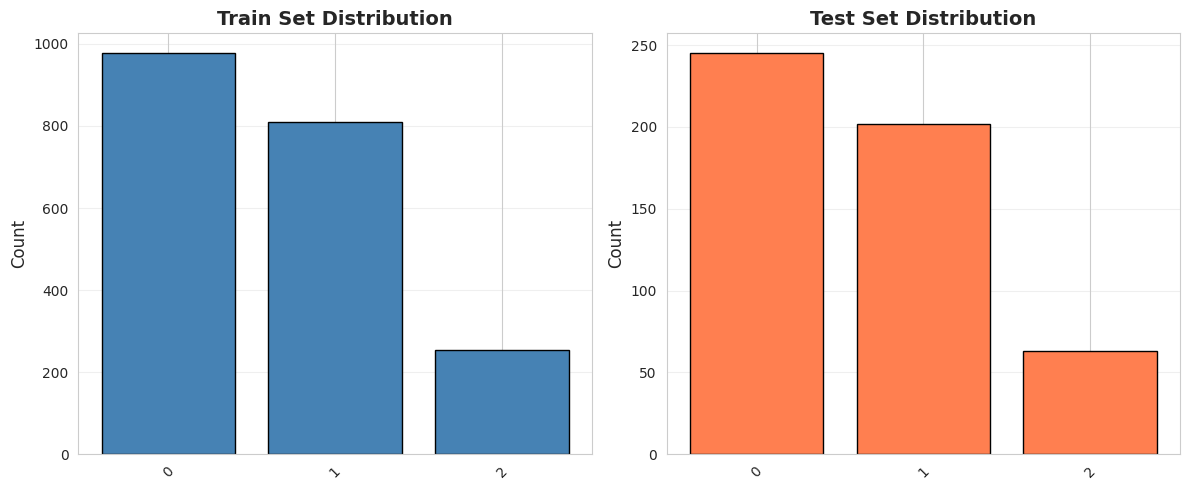

In [ ]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train set
y_train_counts = y_train.value_counts().sort_index()
if label_encoder:
    labels = [label_encoder.classes_[i] for i in y_train_counts.index]
else:
    labels = y_train_counts.index

axes[0].bar(range(len(y_train_counts)), y_train_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(y_train_counts)))
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_title('Train Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Test set
y_test_counts = y_test.value_counts().sort_index()
if label_encoder:
    labels = [label_encoder.classes_[i] for i in y_test_counts.index]
else:
    labels = y_test_counts.index

axes[1].bar(range(len(y_test_counts)), y_test_counts.values, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(y_test_counts)))
axes[1].set_xticklabels(labels, rotation=45)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Initialize Models

In [ ]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("INITIALIZING MODELS")

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        n_jobs=-1
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=1,
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss"
),
}

print(f"Models initialized:")
for name, model in models.items():
    print(f"  {name}")

print(f"{len(models)} models ready for training!")

INITIALIZING MODELS
Models initialized:
  Logistic Regression
  Random Forest
  XGBoost
3 models ready for training!


# Train Models

In [ ]:
print("TRAINING MODELS")

# Dictionary to store trained models
trained_models = {}
training_times = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Time the training
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    training_time = end_time - start_time
    training_times[name] = training_time
    trained_models[name] = model

    print(f"Completed in {training_time:.2f} seconds")

print("ALL MODELS TRAINED SUCCESSFULLY!")

TRAINING MODELS

Training Logistic Regression...
Completed in 17.48 seconds

Training Random Forest...
Completed in 3.72 seconds

Training XGBoost...
Completed in 529.13 seconds
ALL MODELS TRAINED SUCCESSFULLY!


# Make Predictions

In [ ]:
print("GENERATING PREDICTIONS")

# Store predictions
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    # Predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Probabilities (for ROC curves)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)
        probabilities[name] = y_prob

    print(f"{name}: {len(y_pred)} predictions generated")


GENERATING PREDICTIONS
Logistic Regression: 510 predictions generated
Random Forest: 510 predictions generated
XGBoost: 510 predictions generated


# Evaluate Models


In [ ]:
print("MODEL EVALUATION")

# Store results
results = []

for name in trained_models.keys():
    y_pred = predictions[name]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_times[name]
    })

    # Print individual results
    print(f"{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("SUMMARY TABLE")
display(results_df)

MODEL EVALUATION
Logistic Regression:
  Accuracy:  0.7098
  Precision: 0.7113
  Recall:    0.7098
  F1-Score:  0.7104
Random Forest:
  Accuracy:  0.7118
  Precision: 0.7155
  Recall:    0.7118
  F1-Score:  0.7031
XGBoost:
  Accuracy:  0.7569
  Precision: 0.7575
  Recall:    0.7569
  F1-Score:  0.7517
SUMMARY TABLE


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Logistic Regression,0.7098,0.7113,0.7098,0.7104,17.4767
1,Random Forest,0.7118,0.7155,0.7118,0.7031,3.7177
2,XGBoost,0.7569,0.7575,0.7569,0.7517,529.1318


# Cross-Validation

In [47]:
print("CROSS-VALIDATION ANALYSIS (5-Fold)")

cv_results = []
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trained_models.items():
    print(f"Cross-validating {name}...")

    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_strategy,
        scoring='accuracy',
        n_jobs=1
    )

    cv_results.append({
        'Model': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'CV Min': cv_scores.min(),
        'CV Max': cv_scores.max(),
        'All Folds': cv_scores.tolist()
    })

    print(f"  Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"  Folds: {[f'{s:.4f}' for s in cv_scores]}")

# Create CV DataFrame
cv_df = pd.DataFrame(cv_results)
cv_df_display = cv_df.drop('All Folds', axis=1).round(4)

print("CROSS-VALIDATION SUMMARY")
display(cv_df_display)

CROSS-VALIDATION ANALYSIS (5-Fold)
Cross-validating Logistic Regression...
  Mean Accuracy: 0.6858 (±0.0201)
  Folds: ['0.7034', '0.7059', '0.6667', '0.6961', '0.6569']
Cross-validating Random Forest...
  Mean Accuracy: 0.6873 (±0.0199)
  Folds: ['0.7059', '0.7010', '0.6912', '0.6495', '0.6887']
Cross-validating XGBoost...
  Mean Accuracy: 0.7353 (±0.0239)
  Folds: ['0.7574', '0.7647', '0.7377', '0.7034', '0.7132']
CROSS-VALIDATION SUMMARY


,Model,CV Mean,CV Std,CV Min,CV Max
0,Logistic Regression,0.6858,0.0201,0.6569,0.7059
1,Random Forest,0.6873,0.0199,0.6495,0.7059
2,XGBoost,0.7353,0.0239,0.7034,0.7647


# Confusion Matrices

CONFUSION MATRICES - DETAILED ANALYSIS


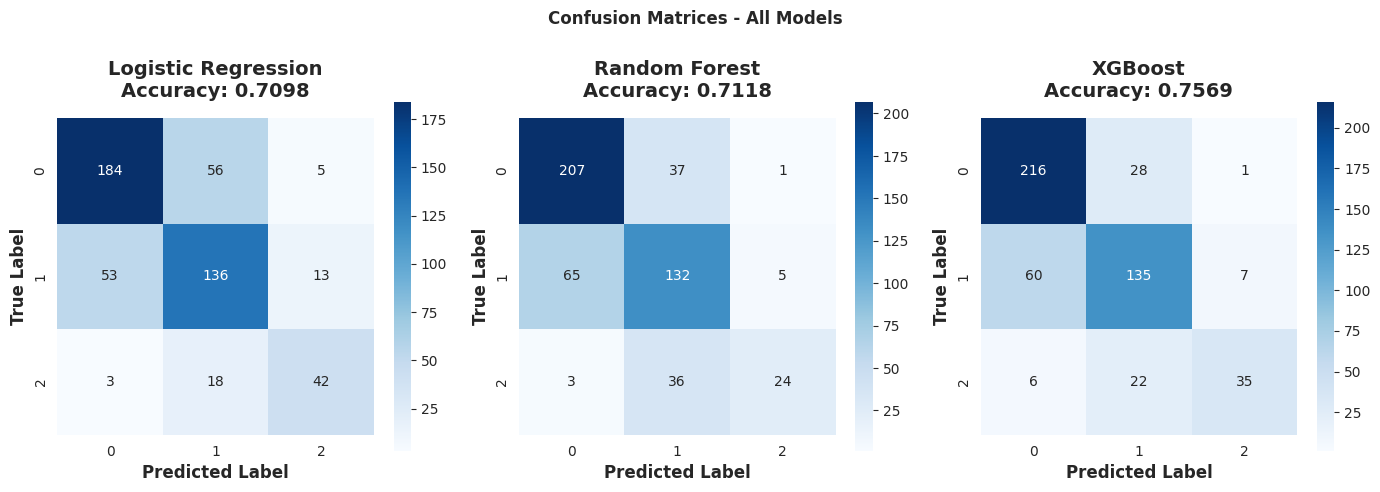

In [48]:
print("CONFUSION MATRICES - DETAILED ANALYSIS")

# Create confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], cbar=True, square=True,
                cbar_kws={'shrink': 0.8})

    # Get accuracy for title
    acc = accuracy_score(y_test, y_pred)

    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}',
                       fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models', fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Classification Reports

In [49]:
print("DETAILED CLASSIFICATION REPORTS")

# Get class names if label encoder was used
try:
    if label_encoder is not None:
        target_names = label_encoder.classes_
    else:
        target_names = None
except:
    target_names = None

for name in trained_models.keys():
    y_pred = predictions[name]

    print(f"{name}")

    if target_names is not None:
        print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    else:
        print(classification_report(y_test, y_pred, zero_division=0))

DETAILED CLASSIFICATION REPORTS
Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       245
           1       0.65      0.67      0.66       202
           2       0.70      0.67      0.68        63

    accuracy                           0.71       510
   macro avg       0.70      0.70      0.70       510
weighted avg       0.71      0.71      0.71       510

Random Forest
              precision    recall  f1-score   support

           0       0.75      0.84      0.80       245
           1       0.64      0.65      0.65       202
           2       0.80      0.38      0.52        63

    accuracy                           0.71       510
   macro avg       0.73      0.63      0.65       510
weighted avg       0.72      0.71      0.70       510

XGBoost
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       245
           1       0.73      0.67      0.70       202
 

# ROC Curves -Reciever Operative curve

ROC CURVES


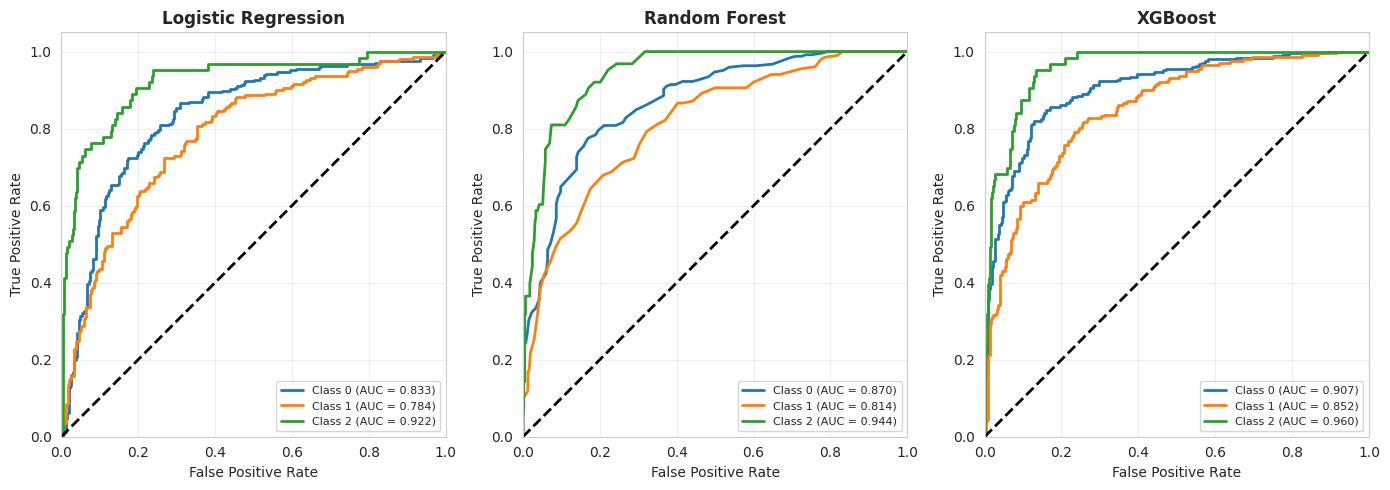

In [50]:
 print("ROC CURVES")

# Determine number of classes
n_classes = len(np.unique(y_train))

if n_classes == 2:
    # Binary classification
    plt.figure(figsize=(16, 12))

    for name in trained_models.keys():
        if name in probabilities:
            y_prob = probabilities[name][:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)

            plt.plot(fpr, tpr, linewidth=2,
                    label=f'{name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Binary Classification', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:

    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes = axes.flatten()

    for idx, name in enumerate(trained_models.keys()):
        if name in probabilities:
            y_prob = probabilities[name]

            # Compute ROC curve and AUC for each class
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc = auc(fpr, tpr)
                axes[idx].plot(fpr, tpr, linewidth=2,
                             label=f'Class {i} (AUC = {roc_auc:.3f})')

            axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=2)
            axes[idx].set_xlim([0.0, 1.0])
            axes[idx].set_ylim([0.0, 1.05])
            axes[idx].set_xlabel('False Positive Rate', fontsize=10)
            axes[idx].set_ylabel('True Positive Rate', fontsize=10)
            axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
            axes[idx].legend(loc='lower right', fontsize=8)
            axes[idx].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Model Comparison Visualization

MODEL COMPARISON


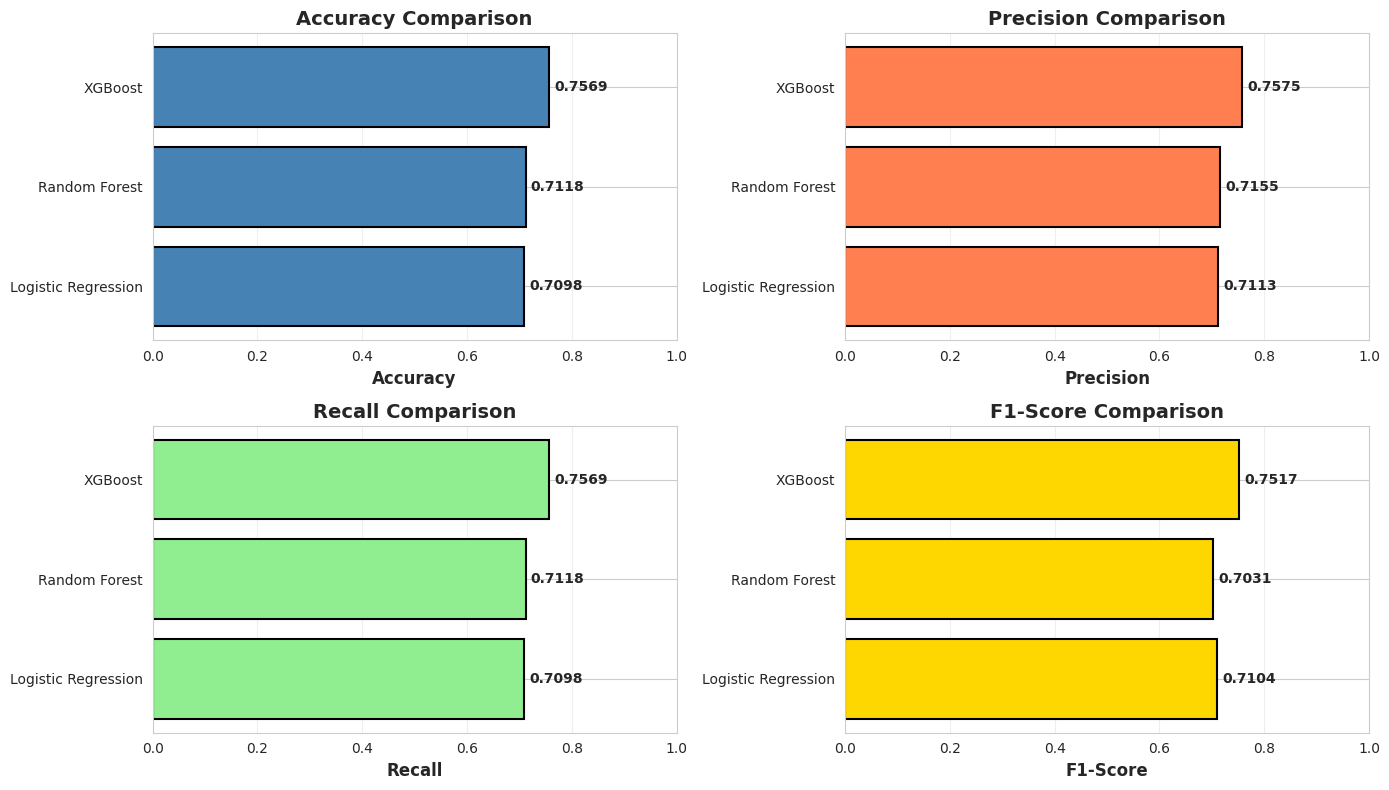

In [51]:
print("MODEL COMPARISON")

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'lightgreen', 'gold']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    values = results_df[metric].values
    models_list = results_df['Model'].values

    bars = ax.barh(models_list, values, color=colors[idx], edgecolor='black', linewidth=1.5)

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + 0.01, i, f'{val:.4f}',
               va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Best Model Selection

In [52]:
print("BEST MODEL SELECTION")

# Find best model by accuracy
best_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_accuracy = results_df.loc[best_idx, 'Accuracy']

print(f"\n🥇 Best Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Precision: {results_df.loc[best_idx, 'Precision']:.4f}")
print(f"   Recall: {results_df.loc[best_idx, 'Recall']:.4f}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1-Score']:.4f}")

# Rank all models
print("Model Ranking:")
ranked = results_df.sort_values('Accuracy', ascending=False)
for i, (idx, row) in enumerate(ranked.iterrows(), 1):
    medal = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"{medal} {i}. {row['Model']}: {row['Recall']:.4f}")

BEST MODEL SELECTION

🥇 Best Model: XGBoost
   Accuracy: 0.7569
   Precision: 0.7575
   Recall: 0.7569
   F1-Score: 0.7517
Model Ranking:
🥇 1. XGBoost: 0.7569
🥈 2. Random Forest: 0.7118
🥉 3. Logistic Regression: 0.7098


# Feature Importance (XGBoost)


FEATURE IMPORTANCE ANALYSIS
XGBoost - Top 5 Features:
  PHC_t1seg_left_hippocampus_rd_median: 0.021614
  jhu_hippocampus_freewater_mean: 0.021047
  t1seg_left_hippocampus_freewater_mean: 0.019498
  t1seg_right_hippocampus_rd_mean: 0.007271
  t1seg_right_mfg_middle_frontal_gyrus_fwcorrected_ad_mean: 0.005797


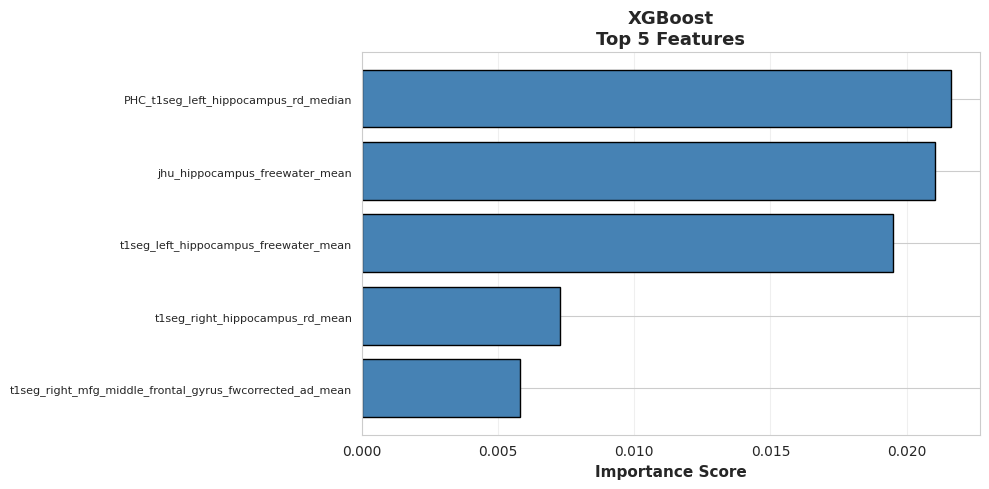

In [53]:
print("FEATURE IMPORTANCE ANALYSIS")

# Models with feature importance
importance_models = ['XGBoost']

# Create a single figure and axes for the plot
# If there were multiple models, we would adjust nrows/ncols and iterate through the axes array
fig, ax = plt.subplots(figsize=(10, 5))

for idx, name in enumerate(importance_models):
    model = trained_models[name]

    # Get feature importance
    importance = model.feature_importances_

    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    # Plot top 5 features
    top_features = importance_df.head(5)

    ax.barh(range(len(top_features)), top_features['Importance'].values,
                  color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Feature'].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nTop 5 Features', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Print top 5
    print(f"{name} - Top 5 Features:")
    for i, row in importance_df.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.6f}")

plt.tight_layout()
plt.show()

# DTI-only vs DTI+Demographics Comparison

In [54]:
print("DTI-ONLY VS DTI+DEMOGRAPHICS COMPARISON")
# Identify demographic features
demographic_features = [
    'PHC_Age_DTI', 'PHC_Sex', 'PHC_Race', 'PHC_Ethnicity', 'PHC_Education'
]

# Filter to only those that exist in the dataset
demographic_features = [col for col in demographic_features if col in X_train.columns]

# DTI-only features (exclude demographics)
dti_only_features = [col for col in X_train.columns if col not in demographic_features]

print(f"Feature Set Definitions:")
print(f"  Total features: {len(X_train.columns)}")
print(f"  Demographic features: {len(demographic_features)}")
for demo in demographic_features:
    print(f"    - {demo}")
print(f"DTI-only features: {len(dti_only_features)}")
print(f"DTI + Demographics: {len(X_train.columns)} (all features)")

# Create DTI-only datasets
X_train_dti_only = X_train[dti_only_features]
X_test_dti_only = X_test[dti_only_features]

# DTI + Demographics (already have this as X_train, X_test)
X_train_with_demo = X_train
X_test_with_demo = X_test


DTI-ONLY VS DTI+DEMOGRAPHICS COMPARISON
Feature Set Definitions:
  Total features: 13750
  Demographic features: 5
    - PHC_Age_DTI
    - PHC_Sex
    - PHC_Race
    - PHC_Ethnicity
    - PHC_Education
DTI-only features: 13745
DTI + Demographics: 13750 (all features)


# Train Models on DTI-Only Features

In [55]:
print("TRAINING MODELS - DTI-ONLY FEATURES")

# Initialize models for DTI-only
models_dti_only = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, n_jobs=1, eval_metric='logloss')

}
# Train models
results_dti_only = []

for name, model in models_dti_only.items():
    print(f"Training {name} (DTI-only)...")

    start = time.time()
    model.fit(X_train_dti_only, y_train)
    train_time = time.time() - start

    # Predict
    y_pred = model.predict(X_test_dti_only)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results_dti_only.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Training_Time': train_time
    })

    print(f" Accuracy: {acc:.4f} (trained in {train_time:.2f}s)")

results_dti_only_df = pd.DataFrame(results_dti_only)

print("DTI-ONLY RESULTS")
display(results_dti_only_df.round(4))

TRAINING MODELS - DTI-ONLY FEATURES
Training Logistic Regression (DTI-only)...
 Accuracy: 0.7118 (trained in 17.39s)
Training Random Forest (DTI-only)...
 Accuracy: 0.7294 (trained in 3.70s)
Training XGBoost (DTI-only)...
 Accuracy: 0.7608 (trained in 524.35s)
DTI-ONLY RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,Training_Time
0,Logistic Regression,0.7118,0.7122,0.7118,0.7119,17.3883
1,Random Forest,0.7294,0.7347,0.7294,0.7235,3.7009
2,XGBoost,0.7608,0.7601,0.7608,0.7566,524.3467


In [56]:
print("COMPARISON: DTI-ONLY VS DTI+DEMOGRAPHICS")

# Create comparison DataFrame
comparison_results = []

for name in models_dti_only.keys():
    # DTI-only results
    dti_only_row = results_dti_only_df[results_dti_only_df['Model'] == name].iloc[0]

    # DTI+Demographics results (from your original results)
    with_demo_row = results_df[results_df['Model'] == name].iloc[0]

    # Calculate improvement
    acc_improvement = with_demo_row['Accuracy'] - dti_only_row['Accuracy']
    acc_improvement_pct = (acc_improvement / dti_only_row['Accuracy']) * 100

    comparison_results.append({
        'Model': name,
        'DTI_Only_Acc': dti_only_row['Accuracy'],
        'DTI+Demo_Acc': with_demo_row['Accuracy'],
        'Improvement': acc_improvement,
        'Improvement_%': acc_improvement_pct,
        'Better_With_Demo': acc_improvement > 0
    })

comparison_df = pd.DataFrame(comparison_results)

print("\nPerformance Comparison:")
display(comparison_df.round(4))


dti_only_accs = comparison_df['DTI_Only_Acc'].values
with_demo_accs = comparison_df['DTI+Demo_Acc'].values

t_stat, p_value = ttest_rel(with_demo_accs, dti_only_accs)

print(f"Statistical Significance Test (Paired t-test):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ SIGNIFICANT: Demographics significantly improve performance (p < 0.05)")
else:
    print(f"  ✗ NOT SIGNIFICANT: No significant improvement with demographics (p >= 0.05)")

COMPARISON: DTI-ONLY VS DTI+DEMOGRAPHICS

Performance Comparison:


,Model,DTI_Only_Acc,DTI+Demo_Acc,Improvement,Improvement_%,Better_With_Demo
0,Logistic Regression,0.7118,0.7098,-0.0020,-0.2760,False
1,Random Forest,0.7294,0.7118,-0.0176,-2.4145,False
2,XGBoost,0.7608,0.7569,-0.0039,-0.5106,False


Statistical Significance Test (Paired t-test):
  t-statistic: -1.5872
  p-value: 0.2534
  ✗ NOT SIGNIFICANT: No significant improvement with demographics (p >= 0.05)


# Variance Filtering

In [57]:
print("IMPROVEMENT 1: VARIANCE FILTERING")

# Apply variance threshold on the already-scaled training data
var_threshold = VarianceThreshold(threshold=0.01)
X_train_vf = var_threshold.fit_transform(X_train)
X_test_vf  = var_threshold.transform(X_test)

# Recover column names for interpretability
retained_mask    = var_threshold.get_support()
retained_cols    = X_train.columns[retained_mask]
n_removed        = X_train.shape[1] - X_train_vf.shape[1]

X_train_vf = pd.DataFrame(X_train_vf, columns=retained_cols, index=X_train.index)
X_test_vf  = pd.DataFrame(X_test_vf,  columns=retained_cols, index=X_test.index)

print(f"Original feature count : {X_train.shape[1]:,}")
print(f"Features removed        : {n_removed:,}  (near-zero variance)")
print(f"Features retained       : {X_train_vf.shape[1]:,}")
print(f"Train shape after VF    : {X_train_vf.shape}")
print(f"Test  shape after VF    : {X_test_vf.shape}")
print("Variance filtering complete")

IMPROVEMENT 1: VARIANCE FILTERING
Original feature count : 13,750
Features removed        : 9  (near-zero variance)
Features retained       : 13,741
Train shape after VF    : (2040, 13741)
Test  shape after VF    : (510, 13741)
Variance filtering complete


# SMOTE (Synthetic Minority Over-sampling Technique)

In [58]:
print("IMPROVEMENT 2: SMOTE — CLASS BALANCING")

print("Class distribution BEFORE SMOTE (train):")
for cls, cnt in sorted(y_train.value_counts().items()):
    lbl = label_encoder.classes_[cls] if label_encoder else str(cls)
    print(f"  Class {cls} ({lbl}): {cnt:,}")

# Apply SMOTE on variance-filtered training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_vf, y_train)

X_train_sm = pd.DataFrame(X_train_sm, columns=retained_cols)
y_train_sm = pd.Series(y_train_sm, name=TARGET_COLUMN)

print(f"Class distribution AFTER SMOTE (train):")
for cls, cnt in sorted(y_train_sm.value_counts().items()):
    lbl = label_encoder.classes_[cls] if label_encoder else str(cls)
    print(f"  Class {cls} ({lbl}): {cnt:,}")

print(f"Samples before SMOTE : {len(X_train_vf):,}")
print(f"Samples after  SMOTE : {len(X_train_sm):,}")
print("SMOTE balancing complete")

IMPROVEMENT 2: SMOTE — CLASS BALANCING
Class distribution BEFORE SMOTE (train):
  Class 0 (0): 977
  Class 1 (1): 809
  Class 2 (2): 254
Class distribution AFTER SMOTE (train):
  Class 0 (0): 977
  Class 1 (1): 977
  Class 2 (2): 977
Samples before SMOTE : 2,040
Samples after  SMOTE : 2,931
SMOTE balancing complete


# RandomizedSearchCV — Hyperparameter Tuning

In [59]:
print("Logistic Regression (class_weight=balanced)")


from sklearn.linear_model import LogisticRegression as _LR
import time as _time
lr_improved = _LR(random_state=42, max_iter=2000, class_weight='balanced', n_jobs=-1)

t0 = _time.time()
lr_improved.fit(X_train_sm, y_train_sm)
lr_time = _time.time() - t0

print(f"Training time: {lr_time:.1f}s")
print("Logistic Regression (improved) training complete")

Logistic Regression (class_weight=balanced)
Training time: 22.2s
Logistic Regression (improved) training complete


In [ ]:
print("RandomizedSearchCV — Random Forest")

rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ),
    param_distributions=rf_param_dist,
    n_iter=8,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1,
    verbose=1
)

import time as _time
t0 = _time.time()
rf_search.fit(X_train_sm, y_train_sm)
rf_tune_time = _time.time() - t0

print("Best RF parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1-weighted  : {rf_search.best_score_:.4f}")
print(f"Tuning time          : {rf_tune_time:.1f}s")
print("Random Forest tuning complete")

RandomizedSearchCV — Random Forest
Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
print("RandomizedSearchCV — XGBoost")

xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

n_cls = len(np.unique(y_train_sm))

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        n_jobs=1,
        tree_method='hist',
        objective='multi:softprob',
        num_class=n_cls,
        eval_metric='mlogloss',
        verbosity=0
    ),
    param_distributions=xgb_param_dist,
    n_iter=8,          # reduced from 30
    cv=3,              # reduced from 5
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1,
    verbose=1
)

t0 = _time.time()
xgb_search.fit(X_train_sm, y_train_sm)
xgb_tune_time = _time.time() - t0

print("Best XGBoost parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV F1-weighted  : {xgb_search.best_score_:.4f}")
print(f"Tuning time          : {xgb_tune_time:.1f}s")
print("XGBoost tuning complete")

# Evaluate Improved Models

In [ ]:
print("EVALUATING IMPROVED MODELS")

improved_models = {
    'Logistic Regression': (lr_improved,       lr_time),
    'Random Forest'      : (rf_search.best_estimator_,  rf_tune_time),
    'XGBoost'            : (xgb_search.best_estimator_, xgb_tune_time),
}

improved_results = []

for name, (model, train_t) in improved_models.items():
    y_pred = model.predict(X_test_vf)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

    improved_results.append({
        'Model'           : name,
        'Accuracy'        : acc,
        'Precision'       : prec,
        'Recall'          : rec,
        'F1-Score'        : f1,
        'Training Time(s)': round(train_t, 2)
    })

    print(f"{name}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")

improved_results_df = pd.DataFrame(improved_results).round(4)

print("IMPROVED MODELS")
display(improved_results_df)

# Comparison Table

In [ ]:
print("ORIGINAL vs IMPROVED")

comparison_enh = []

for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    orig_row = results_df[results_df['Model'] == name].iloc[0]
    impr_row = improved_results_df[improved_results_df['Model'] == name].iloc[0]

    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        delta = impr_row[metric] - orig_row[metric]
        comparison_enh.append({
            'Model'         : name,
            'Metric'        : metric,
            'Original'      : round(orig_row[metric], 4),
            'Improved'      : round(impr_row[metric], 4),
            'Δ Change'      : round(delta, 4),
            'Direction'     : '▲ Better' if delta > 0 else ('▼ Lower' if delta < 0 else '= Same')
        })

comparison_enh_df = pd.DataFrame(comparison_enh)
display(comparison_enh_df)

In [ ]:
print("COMPARISON PLOT: ORIGINAL vs IMPROVED MODELS")

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

x      = np.arange(len(model_names))
width  = 0.35
colors_orig = ['#4C72B0', '#55A868', '#C44E52']   # muted blues/greens/reds
colors_impr = ['#64B5F6', '#81C784', '#E57373']   # lighter variants

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    orig_vals = [
        results_df[results_df['Model'] == m][metric].values[0]
        for m in model_names
    ]
    impr_vals = [
        improved_results_df[improved_results_df['Model'] == m][metric].values[0]
        for m in model_names
    ]

    bars_orig = ax.bar(x - width/2, orig_vals, width,
                       label='Original',  color='#5B8DB8', edgecolor='black', linewidth=0.8)
    bars_impr = ax.bar(x + width/2, impr_vals, width,
                       label='Improved',  color='#E8843A', edgecolor='black', linewidth=0.8)

    # Value labels
    for bar in bars_orig:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2c2c2c')

    for bar in bars_impr:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2c2c2c')

    # Delta annotations (arrow + value above improved bar)
    for i, (ov, iv) in enumerate(zip(orig_vals, impr_vals)):
        delta = iv - ov
        symbol = '▲' if delta > 0 else '▼' if delta < 0 else '='
        clr    = 'green' if delta > 0 else ('red' if delta < 0 else 'gray')
        ax.text(x[i] + width/2, iv + 0.025,
                f'{symbol}{abs(delta):.3f}',
                ha='center', va='bottom', fontsize=8, color=clr, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10, rotation=10)
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} — Original vs Improved', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim([0, 1.12])
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Model Performance: Original vs Enhanced\n'
    '(Variance Filtering + SMOTE + RandomizedSearchCV)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print("Comparison plot")